# Chapter 2 — The kernel as the normal form

*Companion notebook to **The Learned Kernel**, Ch. 2. Run top to bottom.*

Five methods you were taught as separate chapters — Nadaraya–Watson smoothing, kernel
ridge regression (KRR), the support vector machine, the Gaussian-process posterior mean,
and single-head attention — are **one machine**: fix a positive-semidefinite kernel, form
its Gram matrix, solve one linear system. This notebook shows that on the running data,
and pins down the two equalities the algebra forces exactly.

**What you will do here**
1. Derive the KRR weights $w(x)=(K+\lambda I)^{-1}k(x,\cdot)$ and recover Chapter 1's vote.
2. Predict one block five ways under one shared kernel and **assert** the two exact
   identities: $\text{KRR}=\text{GP mean}$ and $\text{attention}=\text{NW}$.
3. **Turn the kernel's knobs** (bandwidth $\ell$, ridge $\lambda$) and watch all five
   predictions move — the kernel is the only real degree of freedom.

**The frame** — *what is learned · how scored · what you read off.* Here the kernel is
held **fixed**; nothing is learned yet. The chapter's job is to build the machine and show
the kernel is its one input. What you read off it: the dual weights (Chapter 1's vote) and
the support vectors.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lkbook import load_california, load_taiwan, set_style
from lkbook.chapters import ch02

set_style()
cal = load_california()
print(f"California: {cal.n} train rows, {cal.d} features")

California: 16512 train rows, 8 features


## 2.1  A kernel is a PSD Gram matrix

Promote Chapter 1's similarity $k(x,x')$ to a **positive-semidefinite** kernel: symmetric,
with $c^\top K c \ge 0$ for every $c$. PSD-ness is what makes $K+\lambda I$ invertible —
its smallest eigenvalue is at least $\lambda>0$. Check it on a sub-sample.

In [3]:
rng = np.random.RandomState(0)
idx = rng.choice(cal.n, 800, replace=False)
ell = ch02.median_lengthscale(cal.Xtr)
K = ch02.rbf_gram(cal.Xtr[idx], cal.Xtr[idx], ell)
eig = np.linalg.eigvalsh(K)
lam = 1e-2
print(f"bandwidth ℓ = {ell:.3f}")
print(f"min eigenvalue of K        = {eig.min():.3e}   (≥ 0 ⟹ PSD)")
print(f"min eigenvalue of K + λI   = {(eig.min() + lam):.3e}   (≥ λ ⟹ invertible)")

bandwidth ℓ = 2.932
min eigenvalue of K        = 5.474e-10   (≥ 0 ⟹ PSD)
min eigenvalue of K + λI   = 1.000e-02   (≥ λ ⟹ invertible)


## 2.2  The reproducing property

A kernel is an inner product in a feature space: $k(x,x')=\langle\phi(x),\phi(x')\rangle$,
and evaluation is an inner product against the kernel slice, $f(x)=\langle f,k(x,\cdot)\rangle$.
That one fact is what collapses the five methods. (Figure 2.1.)

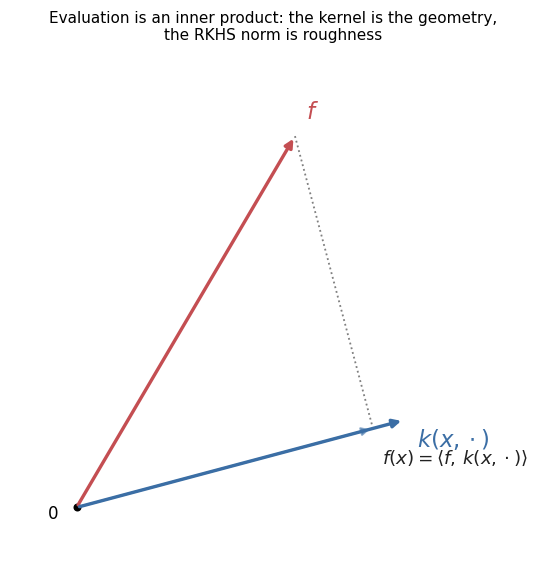

In [4]:
ch02.make_reproducing_figure()
plt.show()

## 2.3  Kernel ridge regression, and Chapter 1's vote returns

Regularized least squares in feature space, reduced by the representer theorem to a finite
solve: $\alpha=(K+\lambda I)^{-1}y$, $\hat y(x)=k(x,\cdot)^\top\alpha$. Equivalently the
weighted vote $\hat y(x)=\sum_i w_i(x)\,y_i$ with $w(x)=(K+\lambda I)^{-1}k(x,\cdot)$.

In [5]:
q = 7
x = cal.Xte[q]
ns = 4000
idx = rng.choice(cal.n, ns, replace=False)
Xtr, ytr = cal.Xtr[idx], cal.ytr[idx]
Kf = ch02.rbf_gram(Xtr, Xtr, ell)
kq = ch02.rbf_gram(x[None], Xtr, ell)[0]

alpha = ch02.krr_alpha(Kf, ytr, lam)         # α = (K+λI)^{-1} y
w = np.linalg.solve(Kf + lam * np.eye(ns), kq)   # w(x) = (K+λI)^{-1} k(x,·)
print(f"KRR via α·k :  {float(kq @ alpha)*100:.1f}k")
print(f"KRR via Σ wᵢyᵢ:  {float(w @ ytr)*100:.1f}k   (the Chapter-1 weighted vote)")
print(f"agree to {abs(kq@alpha - w@ytr):.2e}")

KRR via α·k :  345.7k
KRR via Σ wᵢyᵢ:  345.7k   (the Chapter-1 weighted vote)
agree to 2.44e-12


## 2.4  Four faces of one machine

Predict the same block five ways under **one shared** RBF kernel. Two pairs are locked
together by algebra; the live assertions below would raise if they were not.

In [6]:
preds, info = ch02.one_machine(cal, q=q, ell=ell, lam=lam)
ch02.exact_identities(preds)   # raises unless KRR==GP mean and attention==NW
tbl = pd.DataFrame({"prediction ($k)": {m: round(preds[m] * 100, 1) for m in
                    ("KRR", "GP mean", "NW", "attention", "SVM")}})
print(f"ℓ={info['ell']:.2f}, λ={info['lam']}, SVM support vectors "
      f"= {info['n_support']}/{info['n_train']}")
print(f"KRR − GP mean      = {abs(preds['KRR']-preds['GP mean']):.2e}  (exact)")
print(f"attention − NW     = {abs(preds['attention']-preds['NW']):.2e}  (exact)")
tbl

ℓ=2.93, λ=0.01, SVM support vectors = 3139/4000
KRR − GP mean      = 0.00e+00  (exact)
attention − NW     = 8.88e-16  (exact)


,prediction ($k)
KRR,338.3
GP mean,338.3
NW,215.4
attention,215.4
SVM,321.1


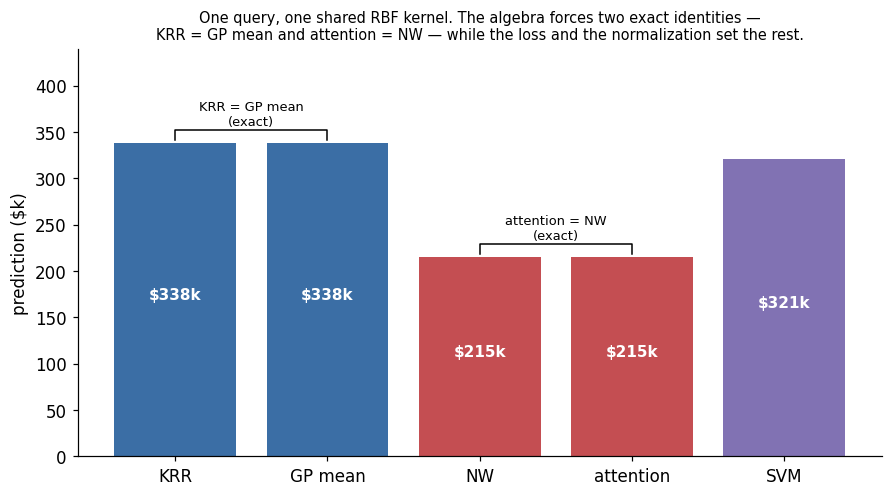

In [7]:
ch02.make_predictions_figure(cal, q=q, ell=ell, lam=lam)
plt.show()

KRR = GP mean and attention = NW, exactly. The SVM (same kernel, hinge loss) lands near
KRR; NW = attention sits lower because a broad normalized smoother averages over a wide
neighborhood. The *kernel* is shared; the loss and the normalization set the spread.

### Turn the only knob that matters: the kernel

The method is fixed once you pick loss and normalization. The geometry — the kernel — is
the real degree of freedom. Sweep the bandwidth $\ell$ and the ridge $\lambda$ and watch
all five predictions move together, with the two exact identities holding at every setting.

In [8]:
from ipywidgets import interact, FloatSlider


def explore(log10_ell=np.log10(ell), log10_lam=-2.0):
    ell_, lam_ = 10.0 ** log10_ell, 10.0 ** log10_lam
    p, info = ch02.one_machine(cal, q=q, ell=ell_, lam=lam_)
    order = ["KRR", "GP mean", "NW", "attention", "SVM"]
    vals = [p[m] * 100 for m in order]
    colors = ["#3b6ea5", "#3b6ea5", "#c44e52", "#c44e52", "#8172b3"]
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.bar(order, vals, color=colors)
    for i, v in enumerate(vals):
        ax.text(i, v + 2, f"${v:.0f}k", ha="center", fontsize=9)
    ax.set_ylim(0, max(vals) * 1.2)
    ax.set_ylabel("prediction ($k)")
    ax.set_title(f"ℓ={ell_:.2f}, λ={lam_:.3g}  —  KRR=GP exact, attention=NW exact "
                 f"(Δ<1e-9); SVM SVs={info['n_support']}")
    plt.show()


interact(explore,
         log10_ell=FloatSlider(min=-0.5, max=1.0, step=0.1, value=float(np.log10(ell)),
                               description="log10 ℓ"),
         log10_lam=FloatSlider(min=-4, max=1, step=0.5, value=-2.0, description="log10 λ"));

interactive(children=(FloatSlider(value=0.4672111440880644, description='log10 ℓ', max=1.0, min=-0.5), FloatSl…

## A second target: Taiwan Credit

The same kernel, decoded two ways: KRR on the 0/1 label gives a class score; the SVM gives
a decision. They agree in sign on a held-out applicant — one separating geometry.

In [9]:
tw = load_taiwan()
print(ch02.taiwan_decision(tw))

{'krr_score': -0.07453607677432955, 'krr_class': 0, 'svm_class': 0, 'n_support': 1821}


## Exercises

Fill in each `# TODO`; the solution is one click away.

**(easy)** Verify $K+\lambda I$ is invertible by bounding its smallest eigenvalue. For the
800-row `K` above, confirm `min(eigvalsh(K)) ≥ -1e-8` (PSD up to numerical error) and that
adding `λ` lifts the spectrum to `≥ λ`.

In [10]:
# TODO: compute min eigenvalue of K and of K + lam*I
min_K = None
min_K_lam = None
print(min_K, min_K_lam)

None None


<details><summary>Solution</summary>

```python
e = np.linalg.eigvalsh(K)
min_K, min_K_lam = float(e.min()), float(e.min() + lam)
print(f"λ_min(K) = {min_K:.2e};  λ_min(K+λI) = {min_K_lam:.2e} ≥ λ = {lam}")
```
</details>

**(medium / ⋆)** Show single-head attention with a **Gaussian** score is exactly
Nadaraya–Watson. Build NW weights `kq / kq.sum()` and attention weights
`softmax(log kq)`, and confirm they are equal — hence the two predictions coincide.

In [11]:
# TODO: build nw_w and attn_w from kq and compare
nw_w = None
attn_w = None

<details><summary>Solution</summary>

```python
nw_w = kq / kq.sum()
attn_w = ch02.softmax(np.log(kq + 1e-300))      # softmax(log k) = k / Σk
print("max |nw_w - attn_w| =", float(np.abs(nw_w - attn_w).max()))
print("predictions:", float(nw_w @ ytr), float(attn_w @ ytr))
```
The dot-product score $q^\top k_i/\sqrt d$ used by real transformers is the *asymmetric*
variant (queries and keys are projected differently); a Gaussian score is the symmetric,
PSD case and reduces exactly to NW.
</details>

---
*Companion to Chapter 2 of **The Learned Kernel**. The kernel, the solves and the figures
come from `lkbook.chapters.ch02` — the same code the book's figures are generated from.*